<a href="https://colab.research.google.com/github/InowaR/colab/blob/main/TransformCloudsLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import random
import numpy as np

# Данные для XOR
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y_true = [0, 1, 1, 0]

# Случайные начальные коэффициенты
w0, w1, w2, w3 = [random.uniform(-1, 1) for _ in range(4)]

# Гиперпараметры
learning_rate = 0.1
max_iterations = 10000
tolerance = 1e-8

def diff_central(func, x, dx=0.01):
    """Численное дифференцирование центральной разностью"""
    return (func(x + dx) - func(x - dx)) / (2 * dx)

# Функция потерь (MSE)
def loss():
    total_error = 0
    for i in range(len(X)):
        x1, x2 = X[i]
        target = y_true[i]
        y_pred = w0 + w1*x1 + w2*x2 + w3*x1*x2
        total_error += (y_pred - target) ** 2
    return total_error / len(X)

# Функции потерь для каждого параметра
def loss_w0(w0_val):
    total_error = 0
    for i in range(len(X)):
        x1, x2 = X[i]
        target = y_true[i]
        y_pred = w0_val + w1*x1 + w2*x2 + w3*x1*x2
        total_error += (y_pred - target) ** 2
    return total_error / len(X)

def loss_w1(w1_val):
    total_error = 0
    for i in range(len(X)):
        x1, x2 = X[i]
        target = y_true[i]
        y_pred = w0 + w1_val*x1 + w2*x2 + w3*x1*x2
        total_error += (y_pred - target) ** 2
    return total_error / len(X)

def loss_w2(w2_val):
    total_error = 0
    for i in range(len(X)):
        x1, x2 = X[i]
        target = y_true[i]
        y_pred = w0 + w1*x1 + w2_val*x2 + w3*x1*x2
        total_error += (y_pred - target) ** 2
    return total_error / len(X)

def loss_w3(w3_val):
    total_error = 0
    for i in range(len(X)):
        x1, x2 = X[i]
        target = y_true[i]
        y_pred = w0 + w1*x1 + w2*x2 + w3_val*x1*x2
        total_error += (y_pred - target) ** 2
    return total_error / len(X)

# Обучение с численным дифференцированием и ранней остановкой
prev_loss = float('inf')

for epoch in range(max_iterations):
    current_loss = loss()

    # Вычисляем градиенты численно
    grad_w0 = diff_central(loss_w0, w0)
    grad_w1 = diff_central(loss_w1, w1)
    grad_w2 = diff_central(loss_w2, w2)
    grad_w3 = diff_central(loss_w3, w3)

    # Обновляем веса
    w0 -= learning_rate * grad_w0
    w1 -= learning_rate * grad_w1
    w2 -= learning_rate * grad_w2
    w3 -= learning_rate * grad_w3

    # Вывод ошибки каждые 100 эпох
    if epoch % 100 == 0:
        print(f"Эпоха {epoch}, Ошибка (MSE): {current_loss:.6f}")

    # Проверка условия ранней остановки
    if abs(prev_loss - current_loss) < tolerance:
        print(f"\nРанняя остановка на эпохе {epoch} (изменение ошибки < {tolerance})")
        break

    prev_loss = current_loss

# Проверка
print("\nРезультаты после обучения:")
for x1, x2 in X:
    y = w0 + w1*x1 + w2*x2 + w3*x1*x2
    print(f"{x1} XOR {x2} = {int(round(y))} (точное значение: {y:.4f})")

print(f"\nИтоговое уравнение (исходный полином):")
print(f"y = {w0:.4f} + {w1:.4f}*x1 + {w2:.4f}*x2 + {w3:.4f}*x1*x2")
print(f"Финальная ошибка (MSE): {loss():.6f}")

Эпоха 0, Ошибка (MSE): 0.433295
Эпоха 100, Ошибка (MSE): 0.079836
Эпоха 200, Ошибка (MSE): 0.018460
Эпоха 300, Ошибка (MSE): 0.004269
Эпоха 400, Ошибка (MSE): 0.000987
Эпоха 500, Ошибка (MSE): 0.000228
Эпоха 600, Ошибка (MSE): 0.000053
Эпоха 700, Ошибка (MSE): 0.000012
Эпоха 800, Ошибка (MSE): 0.000003

Ранняя остановка на эпохе 898 (изменение ошибки < 1e-08)

Результаты после обучения:
0 XOR 0 = 0 (точное значение: 0.0012)
0 XOR 1 = 1 (точное значение: 0.9993)
1 XOR 0 = 1 (точное значение: 0.9993)
1 XOR 1 = 0 (точное значение: 0.0004)

Итоговое уравнение (исходный полином):
y = 0.0012 + 0.9981*x1 + 0.9981*x2 + -1.9969*x1*x2
Финальная ошибка (MSE): 0.000001


[[-2.00000000e+00 -2.00000000e+00]
 [-2.00000000e+00  2.00000000e+00]
 [ 2.00000000e+00 -2.00000000e+00]
 [ 2.00000000e+00  2.00000000e+00]
 [-2.00000000e+00 -2.00000000e+00]
 [ 2.00000000e+00 -2.00000000e+00]
 [-2.00000000e+00  2.00000000e+00]
 [ 2.00000000e+00  2.00000000e+00]
 [-2.22044605e-16 -2.82842712e+00]
 [-2.82842712e+00  2.22044605e-16]
 [ 2.82842712e+00 -2.22044605e-16]
 [ 2.22044605e-16  2.82842712e+00]
 [-2.22044605e-16 -2.82842712e+00]
 [ 2.82842712e+00 -2.22044605e-16]
 [-2.82842712e+00  2.22044605e-16]
 [ 2.22044605e-16  2.82842712e+00]]
[45  0  0]


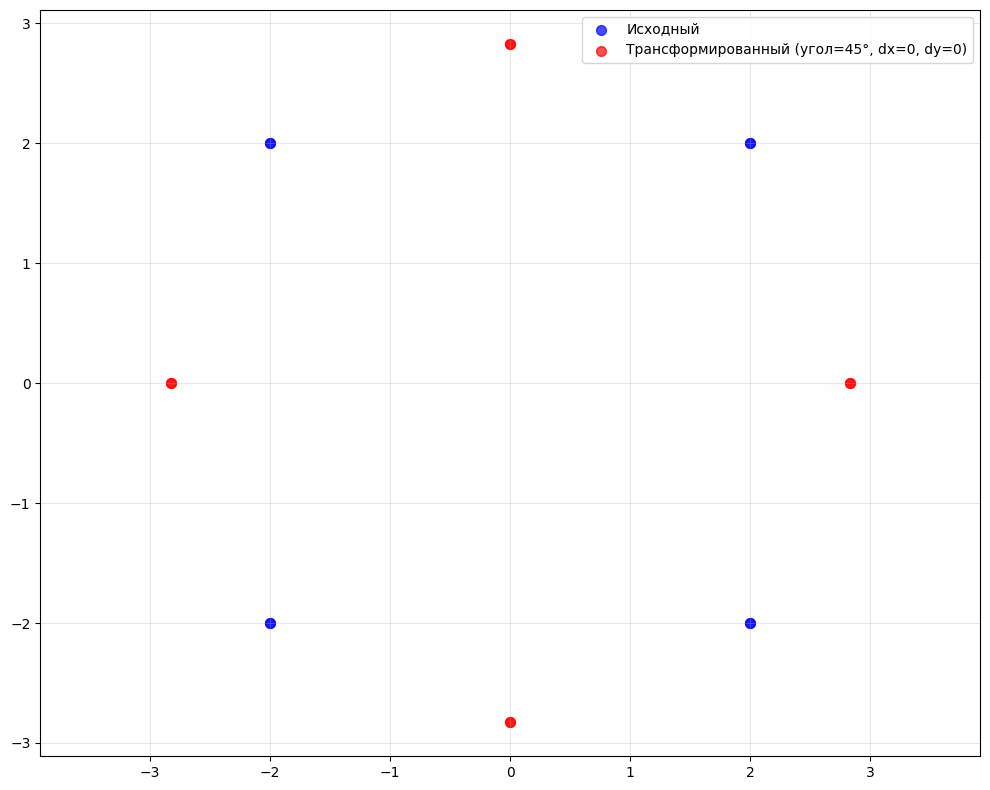

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def create_map(length, width):
    points = []
    half_length = length / 2
    half_width = width / 2

    for x in np.linspace(-half_length, half_length, 2):
        points.append([x, -half_width])
        points.append([x, half_width])

    for y in np.linspace(-half_width, half_width, 2):
        points.append([-half_length, y])
        points.append([half_length, y])

    return np.array(points)

def rotate_points(points, angle_deg):
    angle_rad = np.radians(angle_deg)
    rotation_matrix = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad), np.cos(angle_rad)]
    ])
    return np.dot(points, rotation_matrix.T)

def translate_points(points, dx, dy):
    return points + np.array([dx, dy])

source_rect = create_map(length=4, width=4)

angle = 45
dx = 0
dy = 0

rotated = rotate_points(source_rect, angle)
target_rect = translate_points(rotated, dx, dy)

X = np.vstack([source_rect, target_rect])
y = np.array([angle, dx, dy])

print(X)
print(y)

plt.figure(figsize=(10, 8))

plt.scatter(source_rect[:, 0], source_rect[:, 1],
           c='blue', marker='o', s=50, label='Исходный', alpha=0.7)

plt.scatter(target_rect[:, 0], target_rect[:, 1],
           c='red', marker='o', s=50, label=f'Трансформированный (угол={angle}°, dx={dx}, dy={dy})', alpha=0.7)

plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.tight_layout()

plt.show()
